# ==========================================================
# Data Augmentation using SMOTE, Borderline-SMOTE and ADASYN
# CIC-MalMem-2022 Malware Memory Dataset
# ==========================================================

This notebook builds a **balanced malware dataset** with four classes — **Benign, Ransomware, Spyware, Trojan** — starting from the raw CIC-MalMem-2022 memory-forensics feature dataset, using three oversampling techniques: **SMOTE**, **Borderline-SMOTE**, and **ADASYN**.

## 1. Project Overview

### Objective
Build a **balanced** version of the CIC-MalMem-2022 dataset with a single 4-class target — `Benign`, `Ransomware`, `Spyware`, `Trojan` — derived from the fine-grained `Category` column, and compare three synthetic oversampling techniques (SMOTE, Borderline-SMOTE, ADASYN) for balancing it.

### Why Class Imbalance is a Problem
- The raw dataset has **29,298 Benign** samples but only **~9,500–10,000** samples per malware family (Ransomware, Spyware, Trojan).
- Models trained on imbalanced data are biased toward the majority class (Benign), producing high overall accuracy but **poor recall on minority (malware) classes** — exactly the classes we care most about detecting.
- Standard metrics like accuracy become misleading; the model can "cheat" by mostly predicting Benign.

### Why Data Augmentation is Needed
- Collecting more real-world malware samples is expensive, slow, and sometimes legally/practically constrained.
- **Synthetic oversampling** generates new, plausible minority-class samples in feature space, without duplicating exact rows (which would cause overfitting), so the classifier sees a richer, more balanced view of each class's decision boundary.

### Augmentation Techniques Used
| Technique | Core Idea |
|---|---|
| **SMOTE** | Generates synthetic samples by interpolating between a minority sample and one of its k-nearest minority neighbors. |
| **Borderline-SMOTE** | Only oversamples minority samples that lie near the decision boundary (the "borderline" / hardest-to-classify points), rather than the entire minority class. |
| **ADASYN** | Adaptively generates more synthetic samples for minority samples that are *harder* to learn (i.e., surrounded by more majority-class neighbors), focusing effort where it's needed most. |


## 2. Import Required Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Augmentation techniques
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN

# Utility
import time
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load Preprocessed Dataset

Two loading options are provided:

1. **Kaggle Hub** — loads directly from the `bertvankeulen/cic-malmem-2022` Kaggle dataset (requires Kaggle auth configured in your environment).
2. **Local CSV fallback** — loads the `MalMem2022.csv` file you already uploaded (used automatically if the Kaggle Hub load fails, e.g. no internet/auth in this environment).

We also derive a clean 4-class `Label` column (`Benign`, `Ransomware`, `Spyware`, `Trojan`) from the original fine-grained `Category` column (e.g. `Ransomware-Ako` -> `Ransomware`).

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]

df = None

try:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter

    # Set the path to the file you'd like to load
    file_path = "MalMem2022.csv"

    # Load the latest version
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "bertvankeulen/cic-malmem-2022",
        file_path,
        # Provide any additional arguments like
        # sql_query or pandas_kwargs. See the
        # documentation for more information:
        # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
    )
    print("Loaded dataset via kagglehub.")

except Exception as e:
    print(f"kagglehub load failed ({e}); falling back to local CSV.")
    df = pd.read_csv("MalMem2022.csv")
    print("Loaded dataset from local MalMem2022.csv.")

print("First 5 records:")
df.head()


kagglehub load failed (No module named 'kagglehub'); falling back to local CSV.


Loaded dataset from local MalMem2022.csv.
First 5 records:


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,24,118,0,124,87,0,8,Benign,Benign,Benign


In [3]:
# ------------------------------------------------------------
# Derive a clean 4-class Label column from the fine-grained
# 'Category' column (e.g. 'Ransomware-Ako' -> 'Ransomware').
# ------------------------------------------------------------

def collapse_category(cat):
    if cat == "Benign":
        return "Benign"
    return cat.split("-")[0]

df["Label"] = df["Category"].apply(collapse_category)

print("Derived 'Label' classes:", df["Label"].unique().tolist())
df[["Category", "Label"]].head()


Derived 'Label' classes: ['Benign', 'Ransomware', 'Spyware', 'Trojan']


,Category,Label
0,Benign,Benign
1,Benign,Benign
2,Benign,Benign
3,Benign,Benign
4,Benign,Benign


## 4. Dataset Overview

### Shape

In [4]:
print(f"Dataset shape (rows, columns): {df.shape}")

Dataset shape (rows, columns): (58596, 59)


### Feature Count

In [5]:
non_feature_cols = ["Class", "Category", "Filename", "Label"]
feature_cols = [c for c in df.columns if c not in non_feature_cols]

print(f"Number of features available for modeling: {len(feature_cols)}")
print(feature_cols)


Number of features available for modeling: 55
['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxv

### Target Labels

In [6]:
print("Unique target labels (Label):")
print(df["Label"].unique())
print()
print("Value counts:")
print(df["Label"].value_counts())


Unique target labels (Label):
<StringArray>
['Benign', 'Ransomware', 'Spyware', 'Trojan']
Length: 4, dtype: str

Value counts:
Label
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9487
Name: count, dtype: int64


## 5. Separate Features and Target

### X (Features)
### y (Target)

In [7]:
X = df[feature_cols].copy()
y = df["Label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("X dtypes summary:")
print(X.dtypes.value_counts())


X shape: (58596, 55)
y shape: (58596,)

X dtypes summary:
int64      40
float64    15
Name: count, dtype: int64


## 6. Analyze Original Class Distribution

### Number of Samples per Class

In [8]:
original_counts = y.value_counts()
print("Number of samples per class (original):")
print(original_counts)


Number of samples per class (original):
Label
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9487
Name: count, dtype: int64


### Percentage of Each Class

In [9]:
original_pct = (y.value_counts(normalize=True) * 100).round(2)
print("Percentage of each class (original):")
print(original_pct.astype(str) + " %")


Percentage of each class (original):
Label
Benign         50.0 %
Spyware        17.1 %
Ransomware    16.71 %
Trojan        16.19 %
Name: proportion, dtype: str


## 7. Visualize Original Dataset

### Count Plot
### Pie Chart

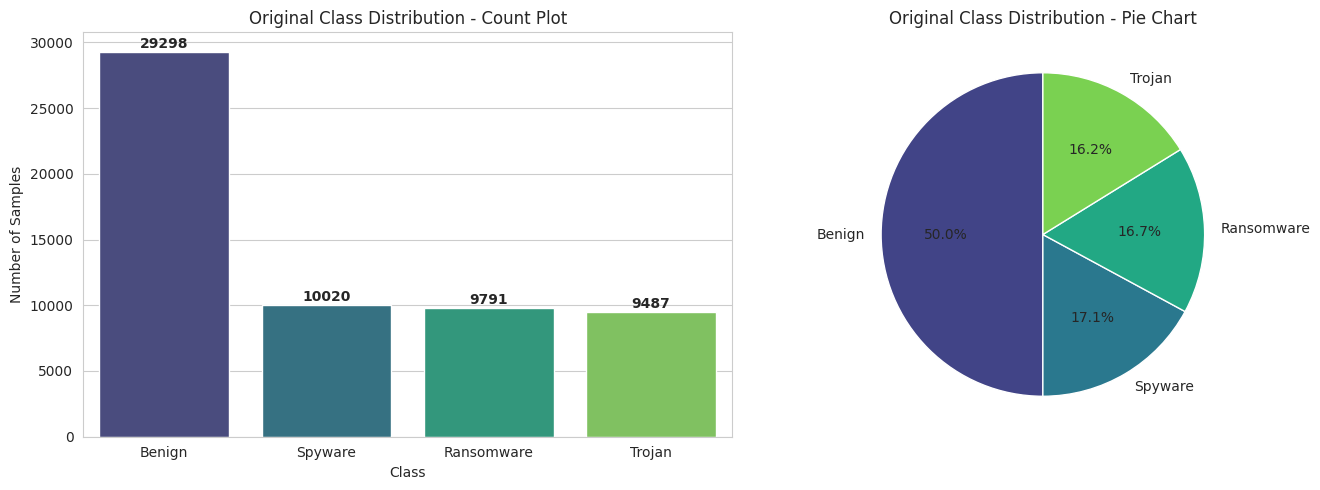

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x=y, order=original_counts.index, palette="viridis", ax=axes[0])
axes[0].set_title("Original Class Distribution - Count Plot")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(original_counts.values):
    axes[0].text(i, v + 300, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(
    original_counts.values,
    labels=original_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("viridis", len(original_counts)),
)
axes[1].set_title("Original Class Distribution - Pie Chart")

plt.tight_layout()
plt.show()


# ==========================================================
# SMOTE
# ==========================================================

## 8. Introduction to SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** creates new synthetic samples for minority classes by:
1. Picking a minority-class sample.
2. Finding its *k* nearest neighbors (also minority class).
3. Randomly selecting one neighbor and creating a new point somewhere along the line segment between the original sample and that neighbor.

This produces synthetic-but-plausible data instead of exact duplicates, which helps reduce overfitting compared to simple random oversampling.

## 9. Apply SMOTE

In [11]:
start_time_smote = time.time()

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

end_time_smote = time.time()
smote_exec_time = end_time_smote - start_time_smote

print(f"SMOTE applied in {smote_exec_time:.3f} seconds.")


SMOTE applied in 2.301 seconds.


## 10. Generate New Dataset

In [12]:
df_smote = X_smote.copy()
df_smote["Label"] = y_smote

print("SMOTE-balanced dataset created.")
df_smote.head()


SMOTE-balanced dataset created.


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Label
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,221,26,24,116,0,121,87,0,8,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,222,26,24,118,0,122,87,0,8,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,222,26,27,118,0,120,88,0,8,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,222,26,27,118,0,120,88,0,8,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,222,26,24,118,0,124,87,0,8,Benign


## 11. Verify Dataset Shape

In [13]:
print(f"Original dataset shape: {df.shape}")
print(f"SMOTE dataset shape    : {df_smote.shape}")


Original dataset shape: (58596, 59)
SMOTE dataset shape    : (117192, 56)


## 12. Verify Class Distribution

In [14]:
smote_counts = y_smote.value_counts()
print("SMOTE class distribution:")
print(smote_counts)


SMOTE class distribution:
Label
Benign        29298
Ransomware    29298
Spyware       29298
Trojan        29298
Name: count, dtype: int64


## 13. Visualize SMOTE Distribution

### Count Plot
### Pie Chart

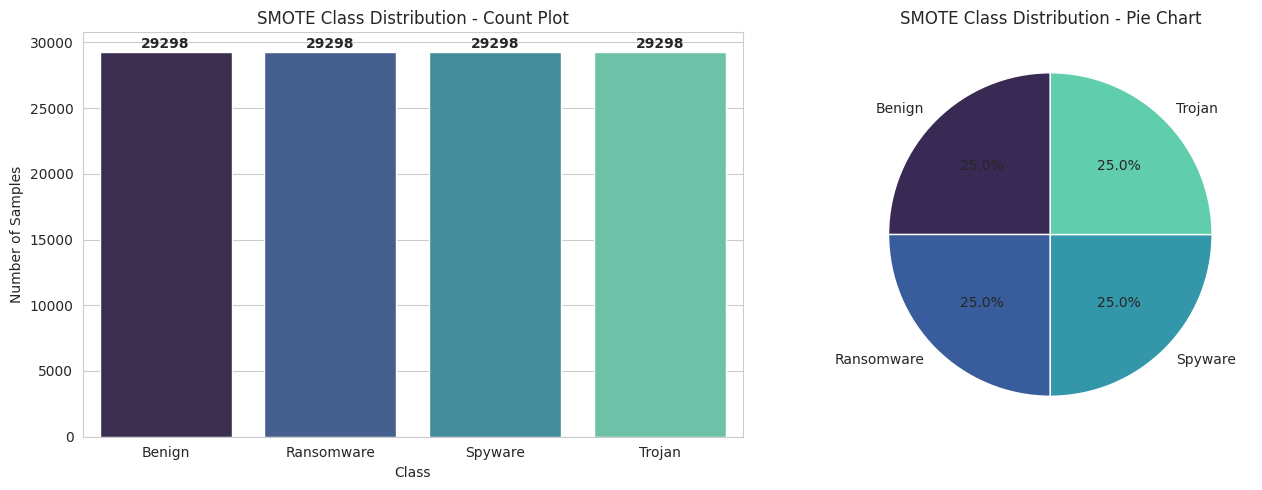

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_smote, order=smote_counts.index, palette="mako", ax=axes[0])
axes[0].set_title("SMOTE Class Distribution - Count Plot")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(smote_counts.values):
    axes[0].text(i, v + 300, str(v), ha="center", fontweight="bold")

axes[1].pie(
    smote_counts.values,
    labels=smote_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("mako", len(smote_counts)),
)
axes[1].set_title("SMOTE Class Distribution - Pie Chart")

plt.tight_layout()
plt.show()


## 14. Calculate Number of Synthetic Samples Generated

In [16]:
synthetic_smote = smote_counts - original_counts
synthetic_smote = synthetic_smote.fillna(0).astype(int)

print("Synthetic samples generated per class (SMOTE):")
print(synthetic_smote)
print(f"\nTotal synthetic samples generated: {synthetic_smote.sum()}")


Synthetic samples generated per class (SMOTE):
Label
Benign            0
Ransomware    19507
Spyware       19278
Trojan        19811
Name: count, dtype: int64

Total synthetic samples generated: 58596


## 15. Save SMOTE Dataset

In [17]:
os.makedirs("outputs", exist_ok=True)
df_smote.to_csv("outputs/MalMem2022_SMOTE.csv", index=False)
print("Saved: outputs/MalMem2022_SMOTE.csv")


Saved: outputs/MalMem2022_SMOTE.csv


# ==========================================================
# Borderline-SMOTE
# ==========================================================

## 16. Introduction to Borderline-SMOTE

**Borderline-SMOTE** is a variant of SMOTE that only generates synthetic samples from minority points that are **near the decision boundary** ("in danger" of being misclassified) rather than from all minority samples. The idea is that samples deep inside the minority region are already easy to classify, so oversampling effort is better spent reinforcing the boundary region, which tends to improve classifier performance more than uniform SMOTE.

## 17. Apply Borderline-SMOTE

In [18]:
start_time_bsmote = time.time()

b_smote = BorderlineSMOTE(random_state=42, kind="borderline-1")
X_bsmote, y_bsmote = b_smote.fit_resample(X, y)

end_time_bsmote = time.time()
bsmote_exec_time = end_time_bsmote - start_time_bsmote

print(f"Borderline-SMOTE applied in {bsmote_exec_time:.3f} seconds.")


Borderline-SMOTE applied in 10.359 seconds.


## 18. Generate New Dataset

In [19]:
df_bsmote = X_bsmote.copy()
df_bsmote["Label"] = y_bsmote

print("Borderline-SMOTE-balanced dataset created.")
df_bsmote.head()


Borderline-SMOTE-balanced dataset created.


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Label
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,221,26,24,116,0,121,87,0,8,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,222,26,24,118,0,122,87,0,8,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,222,26,27,118,0,120,88,0,8,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,222,26,27,118,0,120,88,0,8,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,222,26,24,118,0,124,87,0,8,Benign


## 19. Verify Dataset Shape

In [20]:
print(f"Original dataset shape        : {df.shape}")
print(f"Borderline-SMOTE dataset shape: {df_bsmote.shape}")


Original dataset shape        : (58596, 59)
Borderline-SMOTE dataset shape: (117192, 56)


## 20. Verify Class Distribution

In [21]:
bsmote_counts = y_bsmote.value_counts()
print("Borderline-SMOTE class distribution:")
print(bsmote_counts)


Borderline-SMOTE class distribution:
Label
Benign        29298
Ransomware    29298
Spyware       29298
Trojan        29298
Name: count, dtype: int64


## 21. Visualize Borderline-SMOTE Distribution

### Count Plot
### Pie Chart

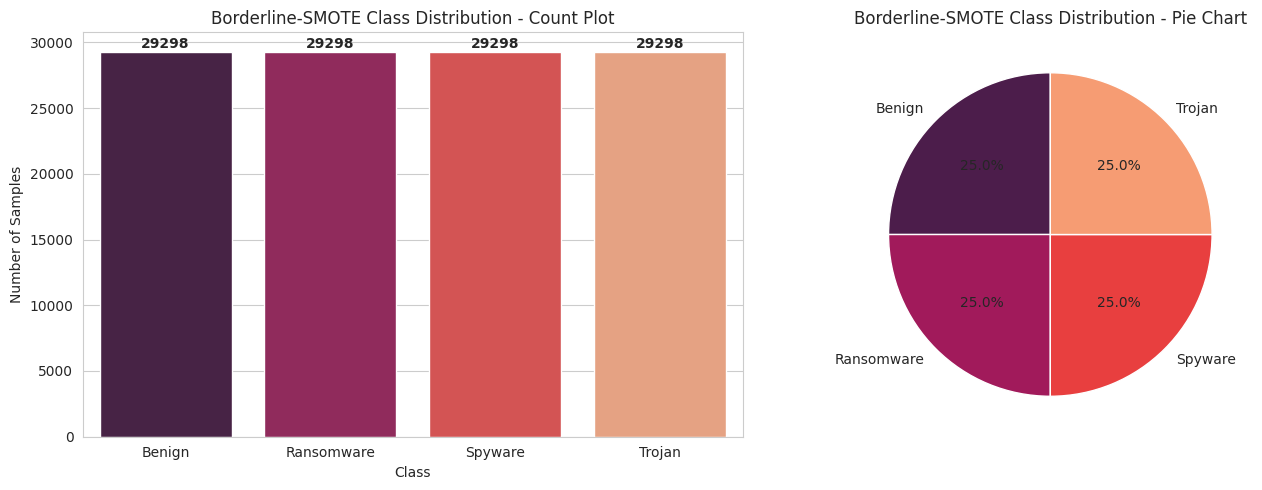

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_bsmote, order=bsmote_counts.index, palette="rocket", ax=axes[0])
axes[0].set_title("Borderline-SMOTE Class Distribution - Count Plot")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(bsmote_counts.values):
    axes[0].text(i, v + 300, str(v), ha="center", fontweight="bold")

axes[1].pie(
    bsmote_counts.values,
    labels=bsmote_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("rocket", len(bsmote_counts)),
)
axes[1].set_title("Borderline-SMOTE Class Distribution - Pie Chart")

plt.tight_layout()
plt.show()


## 22. Calculate Number of Synthetic Samples Generated

In [23]:
synthetic_bsmote = bsmote_counts - original_counts
synthetic_bsmote = synthetic_bsmote.fillna(0).astype(int)

print("Synthetic samples generated per class (Borderline-SMOTE):")
print(synthetic_bsmote)
print(f"\nTotal synthetic samples generated: {synthetic_bsmote.sum()}")


Synthetic samples generated per class (Borderline-SMOTE):
Label
Benign            0
Ransomware    19507
Spyware       19278
Trojan        19811
Name: count, dtype: int64

Total synthetic samples generated: 58596


## 23. Save Borderline-SMOTE Dataset

In [24]:
df_bsmote.to_csv("outputs/MalMem2022_BorderlineSMOTE.csv", index=False)
print("Saved: outputs/MalMem2022_BorderlineSMOTE.csv")


Saved: outputs/MalMem2022_BorderlineSMOTE.csv


# ==========================================================
# ADASYN
# ==========================================================

## 24. Introduction to ADASYN

**ADASYN (Adaptive Synthetic Sampling)** builds on SMOTE's idea but adapts the *number* of synthetic samples generated for each minority sample based on how difficult that sample is to learn — samples surrounded by more majority-class neighbors get more synthetic points generated near them. This adaptively shifts the classifier's decision boundary toward harder-to-learn regions of the minority classes.

## 25. Apply ADASYN

In [25]:
start_time_adasyn = time.time()

adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

end_time_adasyn = time.time()
adasyn_exec_time = end_time_adasyn - start_time_adasyn

print(f"ADASYN applied in {adasyn_exec_time:.3f} seconds.")


ADASYN applied in 11.031 seconds.


## 26. Generate New Dataset

In [26]:
df_adasyn = X_adasyn.copy()
df_adasyn["Label"] = y_adasyn

print("ADASYN-balanced dataset created.")
df_adasyn.head()


ADASYN-balanced dataset created.


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Label
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,221,26,24,116,0,121,87,0,8,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,222,26,24,118,0,122,87,0,8,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,222,26,27,118,0,120,88,0,8,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,222,26,27,118,0,120,88,0,8,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,222,26,24,118,0,124,87,0,8,Benign


## 27. Verify Dataset Shape

In [27]:
print(f"Original dataset shape: {df.shape}")
print(f"ADASYN dataset shape   : {df_adasyn.shape}")


Original dataset shape: (58596, 59)
ADASYN dataset shape   : (117707, 56)


## 28. Verify Class Distribution

In [28]:
adasyn_counts = y_adasyn.value_counts()
print("ADASYN class distribution:")
print(adasyn_counts)
print()
print("Note: ADASYN's adaptive mechanism means class counts may not be perfectly")
print("equal (unlike SMOTE/Borderline-SMOTE), since sample generation is density-based.")


ADASYN class distribution:
Label
Ransomware    29912
Trojan        29597
Benign        29298
Spyware       28900
Name: count, dtype: int64

Note: ADASYN's adaptive mechanism means class counts may not be perfectly
equal (unlike SMOTE/Borderline-SMOTE), since sample generation is density-based.


## 29. Visualize ADASYN Distribution

### Count Plot
### Pie Chart

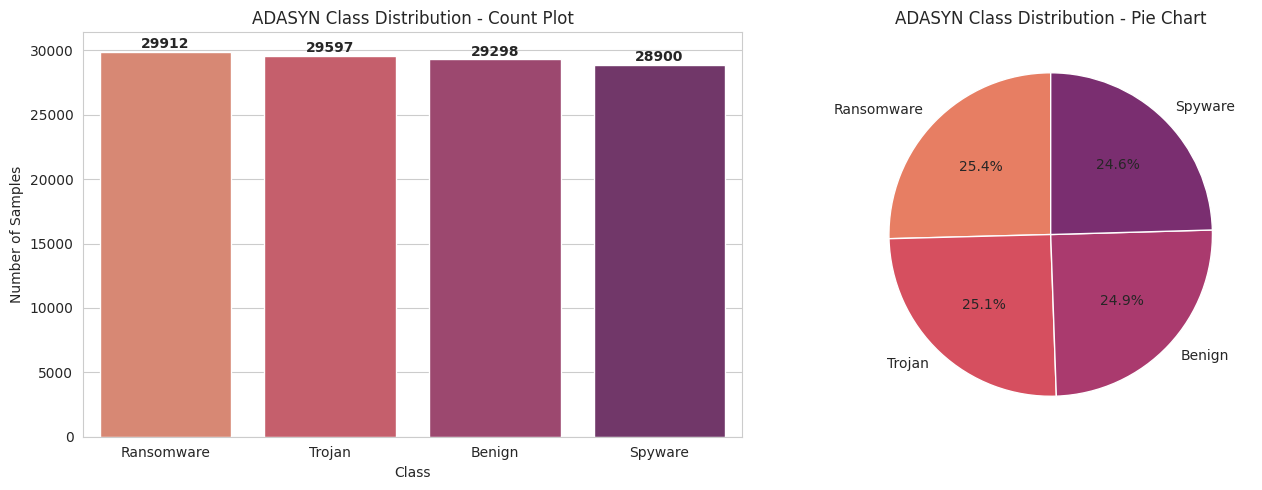

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_adasyn, order=adasyn_counts.index, palette="flare", ax=axes[0])
axes[0].set_title("ADASYN Class Distribution - Count Plot")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(adasyn_counts.values):
    axes[0].text(i, v + 300, str(v), ha="center", fontweight="bold")

axes[1].pie(
    adasyn_counts.values,
    labels=adasyn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("flare", len(adasyn_counts)),
)
axes[1].set_title("ADASYN Class Distribution - Pie Chart")

plt.tight_layout()
plt.show()


## 30. Calculate Number of Synthetic Samples Generated

In [30]:
synthetic_adasyn = adasyn_counts - original_counts
synthetic_adasyn = synthetic_adasyn.fillna(0).astype(int)

print("Synthetic samples generated per class (ADASYN):")
print(synthetic_adasyn)
print(f"\nTotal synthetic samples generated: {synthetic_adasyn.sum()}")


Synthetic samples generated per class (ADASYN):
Label
Benign            0
Ransomware    20121
Spyware       18880
Trojan        20110
Name: count, dtype: int64

Total synthetic samples generated: 59111


## 31. Save ADASYN Dataset

In [31]:
df_adasyn.to_csv("outputs/MalMem2022_ADASYN.csv", index=False)
print("Saved: outputs/MalMem2022_ADASYN.csv")


Saved: outputs/MalMem2022_ADASYN.csv


# ==========================================================
# Comparison of All Techniques
# ==========================================================

## 32. Compare Dataset Shapes

In [32]:
shape_comparison = pd.DataFrame({
    "Dataset": ["Original", "SMOTE", "Borderline-SMOTE", "ADASYN"],
    "Rows": [df.shape[0], df_smote.shape[0], df_bsmote.shape[0], df_adasyn.shape[0]],
    "Columns (incl. Label)": [
        len(feature_cols) + 1,
        df_smote.shape[1],
        df_bsmote.shape[1],
        df_adasyn.shape[1],
    ],
})
shape_comparison


,Dataset,Rows,Columns (incl. Label)
0,Original,58596,56
1,SMOTE,117192,56
2,Borderline-SMOTE,117192,56
3,ADASYN,117707,56


## 33. Compare Class Distributions

In [33]:
distribution_comparison = pd.DataFrame({
    "Original": original_counts,
    "SMOTE": smote_counts,
    "Borderline-SMOTE": bsmote_counts,
    "ADASYN": adasyn_counts,
}).fillna(0).astype(int)

distribution_comparison


,Original,SMOTE,Borderline-SMOTE,ADASYN
Label,,,,
Benign,29298,29298,29298,29298
Ransomware,9791,29298,29298,29912
Spyware,10020,29298,29298,28900
Trojan,9487,29298,29298,29597


## 34. Compare Number of Synthetic Samples

In [34]:
synthetic_comparison = pd.DataFrame({
    "SMOTE": synthetic_smote,
    "Borderline-SMOTE": synthetic_bsmote,
    "ADASYN": synthetic_adasyn,
}).fillna(0).astype(int)

synthetic_comparison.loc["Total"] = synthetic_comparison.sum()
synthetic_comparison


,SMOTE,Borderline-SMOTE,ADASYN
Label,,,
Benign,0,0,0
Ransomware,19507,19507,20121
Spyware,19278,19278,18880
Trojan,19811,19811,20110
Total,58596,58596,59111


## 35. Compare Minority Class Improvement

In [35]:
minority_classes = [c for c in original_counts.index if c != original_counts.idxmax()]

improvement = pd.DataFrame({
    "Original": original_counts[minority_classes],
    "SMOTE": smote_counts[minority_classes],
    "Borderline-SMOTE": bsmote_counts[minority_classes],
    "ADASYN": adasyn_counts[minority_classes],
})

improvement["SMOTE % Increase"] = (
    (improvement["SMOTE"] - improvement["Original"]) / improvement["Original"] * 100
).round(1)
improvement["Borderline-SMOTE % Increase"] = (
    (improvement["Borderline-SMOTE"] - improvement["Original"]) / improvement["Original"] * 100
).round(1)
improvement["ADASYN % Increase"] = (
    (improvement["ADASYN"] - improvement["Original"]) / improvement["Original"] * 100
).round(1)

improvement


,Original,SMOTE,Borderline-SMOTE,ADASYN,SMOTE % Increase,Borderline-SMOTE % Increase,ADASYN % Increase
Label,,,,,,,
Spyware,10020,29298,29298,28900,192.4,192.4,188.4
Ransomware,9791,29298,29298,29912,199.2,199.2,205.5
Trojan,9487,29298,29298,29597,208.8,208.8,212.0


## 36. Create Comparison Table

In [36]:
comparison_table = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Number of Classes",
        "Max Class Count",
        "Min Class Count",
        "Class Balance Ratio (min/max)",
        "Total Synthetic Samples Added",
        "Execution Time (s)",
    ],
    "Original": [
        df.shape[0], y.nunique(), original_counts.max(), original_counts.min(),
        round(original_counts.min() / original_counts.max(), 3), 0, 0.0,
    ],
    "SMOTE": [
        df_smote.shape[0], y_smote.nunique(), smote_counts.max(), smote_counts.min(),
        round(smote_counts.min() / smote_counts.max(), 3),
        int(synthetic_smote.sum()), round(smote_exec_time, 3),
    ],
    "Borderline-SMOTE": [
        df_bsmote.shape[0], y_bsmote.nunique(), bsmote_counts.max(), bsmote_counts.min(),
        round(bsmote_counts.min() / bsmote_counts.max(), 3),
        int(synthetic_bsmote.sum()), round(bsmote_exec_time, 3),
    ],
    "ADASYN": [
        df_adasyn.shape[0], y_adasyn.nunique(), adasyn_counts.max(), adasyn_counts.min(),
        round(adasyn_counts.min() / adasyn_counts.max(), 3),
        int(synthetic_adasyn.sum()), round(adasyn_exec_time, 3),
    ],
})

comparison_table


,Metric,Original,SMOTE,Borderline-SMOTE,ADASYN
0,Total Samples,58596.000,117192.000,117192.000,117707.000
1,Number of Classes,4.000,4.000,4.000,4.000
2,Max Class Count,29298.000,29298.000,29298.000,29912.000
3,Min Class Count,9487.000,29298.000,29298.000,28900.000
4,Class Balance Ratio (min/max),0.324,1.000,1.000,0.966
5,Total Synthetic Samples Added,0.000,58596.000,58596.000,59111.000
6,Execution Time (s),0.000,2.301,10.359,11.031


## 37. Create Bar Chart Comparison

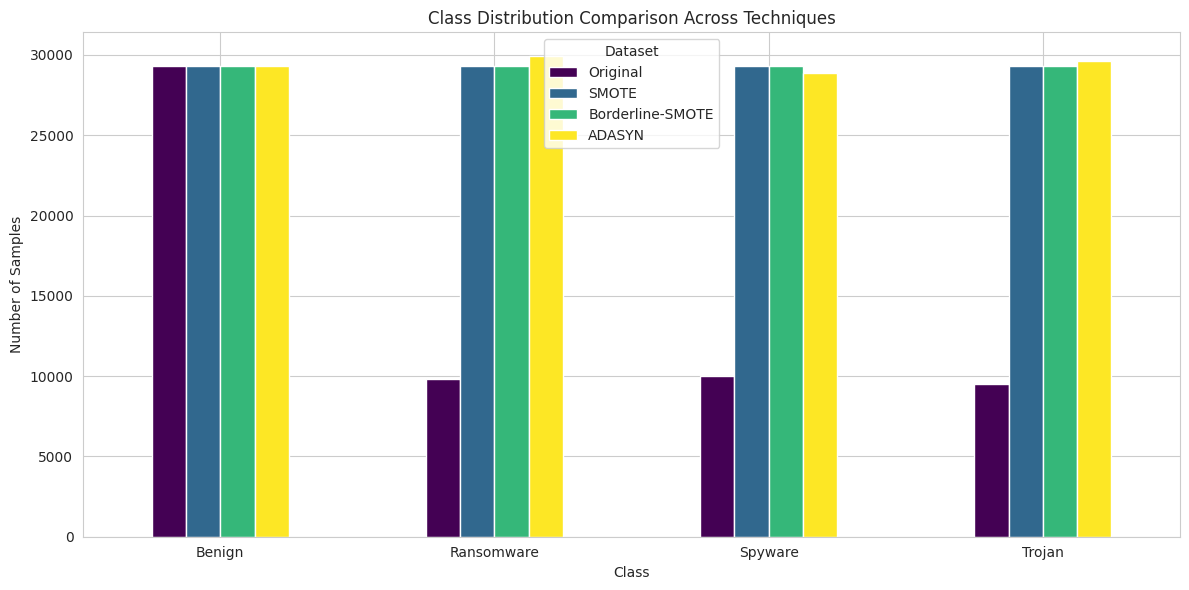

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))
distribution_comparison.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Class Distribution Comparison Across Techniques")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
ax.legend(title="Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 38. Create Pie Chart Comparison

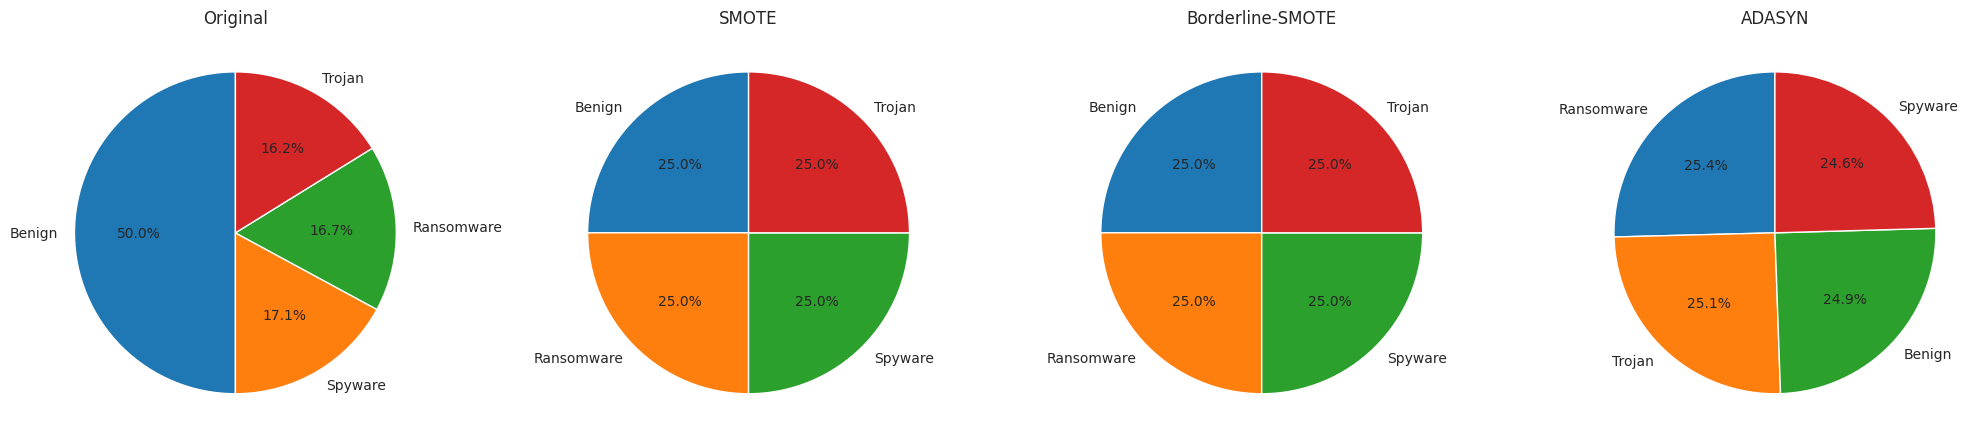

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

datasets_pie = [
    ("Original", original_counts),
    ("SMOTE", smote_counts),
    ("Borderline-SMOTE", bsmote_counts),
    ("ADASYN", adasyn_counts),
]

for ax, (name, counts) in zip(axes, datasets_pie):
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## 39. Create Stacked Bar Chart

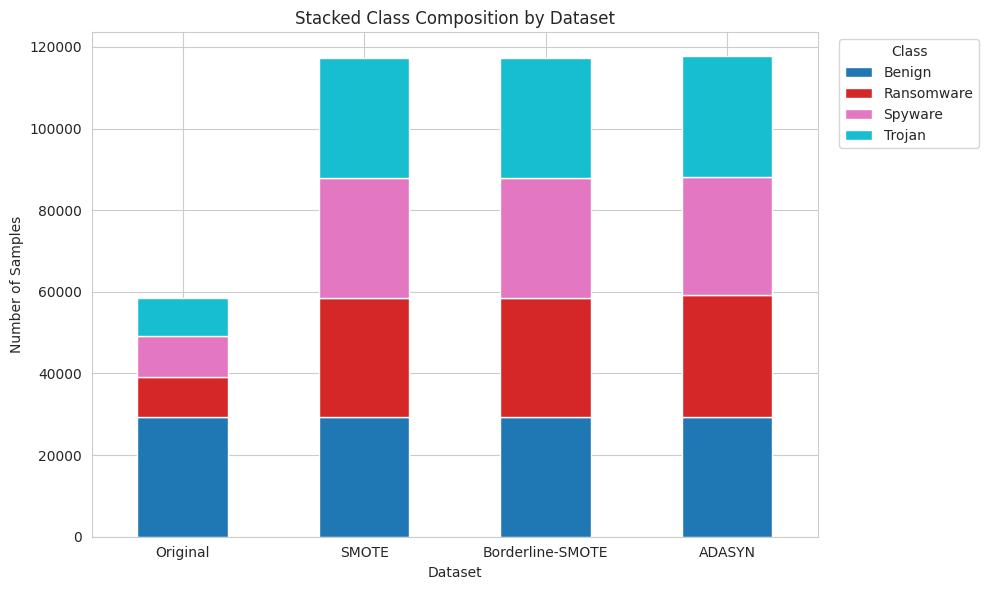

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
distribution_comparison.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Stacked Class Composition by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Number of Samples")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 40. Compare Class Balance Ratio

In [40]:
balance_ratio = pd.DataFrame({
    "Dataset": ["Original", "SMOTE", "Borderline-SMOTE", "ADASYN"],
    "Min/Max Ratio": [
        round(original_counts.min() / original_counts.max(), 3),
        round(smote_counts.min() / smote_counts.max(), 3),
        round(bsmote_counts.min() / bsmote_counts.max(), 3),
        round(adasyn_counts.min() / adasyn_counts.max(), 3),
    ],
})
balance_ratio["Balance %"] = (balance_ratio["Min/Max Ratio"] * 100).round(1)

balance_ratio


,Dataset,Min/Max Ratio,Balance %
0,Original,0.324,32.4
1,SMOTE,1.000,100.0
2,Borderline-SMOTE,1.000,100.0
3,ADASYN,0.966,96.6


## 41. Compare Execution Time

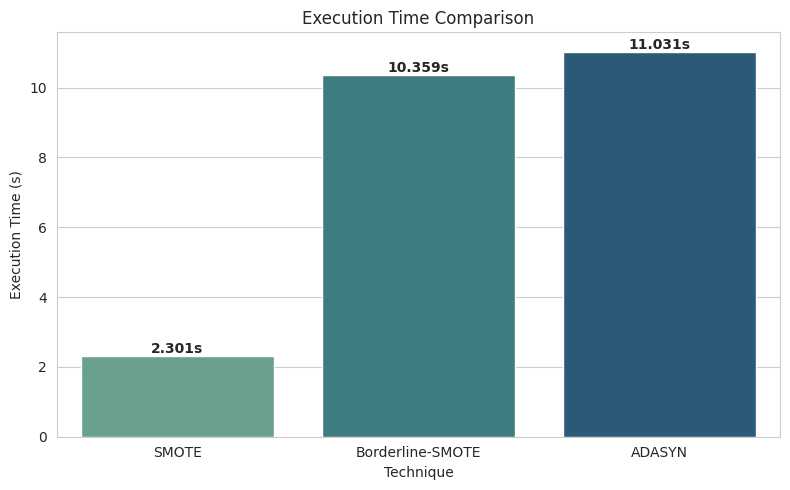

,Technique,Execution Time (s)
0,SMOTE,2.300926
1,Borderline-SMOTE,10.358958
2,ADASYN,11.031470


In [41]:
exec_time_df = pd.DataFrame({
    "Technique": ["SMOTE", "Borderline-SMOTE", "ADASYN"],
    "Execution Time (s)": [smote_exec_time, bsmote_exec_time, adasyn_exec_time],
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=exec_time_df, x="Technique", y="Execution Time (s)", palette="crest", ax=ax)
ax.set_title("Execution Time Comparison")
for i, v in enumerate(exec_time_df["Execution Time (s)"]):
    ax.text(i, v, f"{v:.3f}s", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

exec_time_df


## 42. Compare Memory Usage

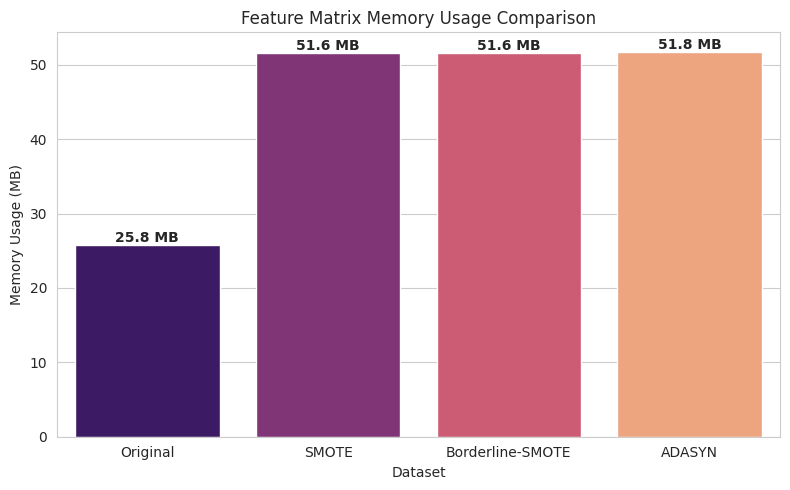

,Dataset,Memory Usage (MB)
0,Original,25.78
1,SMOTE,51.56
2,Borderline-SMOTE,51.56
3,ADASYN,51.79


In [42]:
memory_usage_df = pd.DataFrame({
    "Dataset": ["Original", "SMOTE", "Borderline-SMOTE", "ADASYN"],
    "Memory Usage (MB)": [
        df[feature_cols].memory_usage(deep=True).sum() / 1e6,
        X_smote.memory_usage(deep=True).sum() / 1e6,
        X_bsmote.memory_usage(deep=True).sum() / 1e6,
        X_adasyn.memory_usage(deep=True).sum() / 1e6,
    ],
})
memory_usage_df["Memory Usage (MB)"] = memory_usage_df["Memory Usage (MB)"].round(2)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=memory_usage_df, x="Dataset", y="Memory Usage (MB)", palette="magma", ax=ax)
ax.set_title("Feature Matrix Memory Usage Comparison")
for i, v in enumerate(memory_usage_df["Memory Usage (MB)"]):
    ax.text(i, v, f"{v:.1f} MB", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

memory_usage_df


# ==========================================================
# Validation
# ==========================================================

## 43. Verify No Missing Values

In [43]:
for name, dataset in [("Original", df[feature_cols + ["Label"]]), ("SMOTE", df_smote),
                       ("Borderline-SMOTE", df_bsmote), ("ADASYN", df_adasyn)]:
    n_missing = dataset.isnull().sum().sum()
    print(f"{name:>18}: {n_missing} missing values")


          Original: 0 missing values
             SMOTE: 0 missing values
  Borderline-SMOTE: 0 missing values
            ADASYN: 0 missing values


## 44. Verify No Duplicate Samples

In [44]:
for name, dataset in [("Original", df[feature_cols + ["Label"]]), ("SMOTE", df_smote),
                       ("Borderline-SMOTE", df_bsmote), ("ADASYN", df_adasyn)]:
    n_dupes = dataset.duplicated().sum()
    print(f"{name:>18}: {n_dupes} duplicate rows")


          Original: 559 duplicate rows


             SMOTE: 1113 duplicate rows


  Borderline-SMOTE: 964 duplicate rows


            ADASYN: 912 duplicate rows


## 45. Verify Feature Count Remains Same

In [45]:
for name, dataset in [("SMOTE", X_smote), ("Borderline-SMOTE", X_bsmote), ("ADASYN", X_adasyn)]:
    match = dataset.shape[1] == len(feature_cols)
    print(f"{name:>18}: {dataset.shape[1]} features (matches original: {match})")


             SMOTE: 55 features (matches original: True)
  Borderline-SMOTE: 55 features (matches original: True)
            ADASYN: 55 features (matches original: True)


## 46. Verify Target Labels

In [46]:
for name, labels in [("Original", y), ("SMOTE", y_smote),
                      ("Borderline-SMOTE", y_bsmote), ("ADASYN", y_adasyn)]:
    same_labels = set(labels.unique()) == set(y.unique())
    print(f"{name:>18}: classes = {sorted(labels.unique())} (matches original set: {same_labels})")


          Original: classes = ['Benign', 'Ransomware', 'Spyware', 'Trojan'] (matches original set: True)
             SMOTE: classes = ['Benign', 'Ransomware', 'Spyware', 'Trojan'] (matches original set: True)
  Borderline-SMOTE: classes = ['Benign', 'Ransomware', 'Spyware', 'Trojan'] (matches original set: True)
            ADASYN: classes = ['Benign', 'Ransomware', 'Spyware', 'Trojan'] (matches original set: True)


## 47. Verify Data Types

In [47]:
for name, dataset in [("Original", X), ("SMOTE", X_smote),
                      ("Borderline-SMOTE", X_bsmote), ("ADASYN", X_adasyn)]:
    print(f"{name}:")
    print(dataset.dtypes.value_counts())
    print()


Original:
int64      40
float64    15
Name: count, dtype: int64

SMOTE:
int64      40
float64    15
Name: count, dtype: int64

Borderline-SMOTE:
int64      40
float64    15
Name: count, dtype: int64

ADASYN:
int64      40
float64    15
Name: count, dtype: int64



# ==========================================================
# Export Datasets
# ==========================================================

All three balanced datasets were already saved during their respective sections (15, 23, 31). This section re-confirms the exports and lists the final output files.

## 48. Save SMOTE Dataset

In [48]:
df_smote.to_csv("outputs/MalMem2022_SMOTE.csv", index=False)
print("Confirmed saved: outputs/MalMem2022_SMOTE.csv")


Confirmed saved: outputs/MalMem2022_SMOTE.csv


## 49. Save Borderline-SMOTE Dataset

In [49]:
df_bsmote.to_csv("outputs/MalMem2022_BorderlineSMOTE.csv", index=False)
print("Confirmed saved: outputs/MalMem2022_BorderlineSMOTE.csv")


Confirmed saved: outputs/MalMem2022_BorderlineSMOTE.csv


## 50. Save ADASYN Dataset

In [50]:
df_adasyn.to_csv("outputs/MalMem2022_ADASYN.csv", index=False)
print("Confirmed saved: outputs/MalMem2022_ADASYN.csv")

print("\nAll files in outputs/:")
print(os.listdir("outputs"))


Confirmed saved: outputs/MalMem2022_ADASYN.csv

All files in outputs/:
['MalMem2022_BorderlineSMOTE.csv', 'MalMem2022_SMOTE.csv', 'MalMem2022_ADASYN.csv']


# ==========================================================
# Summary
# ==========================================================

## 51. Original Dataset Statistics

In [51]:
print("ORIGINAL DATASET")
print("-" * 40)
print(f"Total samples : {df.shape[0]}")
print(f"Features      : {len(feature_cols)}")
print(f"Classes       : {y.nunique()}")
print(original_counts)
print(f"Balance ratio (min/max): {round(original_counts.min()/original_counts.max(), 3)}")


ORIGINAL DATASET
----------------------------------------
Total samples : 58596
Features      : 55
Classes       : 4
Label
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9487
Name: count, dtype: int64
Balance ratio (min/max): 0.324


## 52. SMOTE Dataset Statistics

In [52]:
print("SMOTE DATASET")
print("-" * 40)
print(f"Total samples : {df_smote.shape[0]}")
print(f"Features      : {X_smote.shape[1]}")
print(f"Classes       : {y_smote.nunique()}")
print(smote_counts)
print(f"Balance ratio (min/max): {round(smote_counts.min()/smote_counts.max(), 3)}")
print(f"Synthetic samples added: {int(synthetic_smote.sum())}")
print(f"Execution time: {smote_exec_time:.3f}s")


SMOTE DATASET
----------------------------------------
Total samples : 117192
Features      : 55
Classes       : 4
Label
Benign        29298
Ransomware    29298
Spyware       29298
Trojan        29298
Name: count, dtype: int64
Balance ratio (min/max): 1.0
Synthetic samples added: 58596
Execution time: 2.301s


## 53. Borderline-SMOTE Dataset Statistics

In [53]:
print("BORDERLINE-SMOTE DATASET")
print("-" * 40)
print(f"Total samples : {df_bsmote.shape[0]}")
print(f"Features      : {X_bsmote.shape[1]}")
print(f"Classes       : {y_bsmote.nunique()}")
print(bsmote_counts)
print(f"Balance ratio (min/max): {round(bsmote_counts.min()/bsmote_counts.max(), 3)}")
print(f"Synthetic samples added: {int(synthetic_bsmote.sum())}")
print(f"Execution time: {bsmote_exec_time:.3f}s")


BORDERLINE-SMOTE DATASET
----------------------------------------
Total samples : 117192
Features      : 55
Classes       : 4
Label
Benign        29298
Ransomware    29298
Spyware       29298
Trojan        29298
Name: count, dtype: int64
Balance ratio (min/max): 1.0
Synthetic samples added: 58596
Execution time: 10.359s


## 54. ADASYN Dataset Statistics

In [54]:
print("ADASYN DATASET")
print("-" * 40)
print(f"Total samples : {df_adasyn.shape[0]}")
print(f"Features      : {X_adasyn.shape[1]}")
print(f"Classes       : {y_adasyn.nunique()}")
print(adasyn_counts)
print(f"Balance ratio (min/max): {round(adasyn_counts.min()/adasyn_counts.max(), 3)}")
print(f"Synthetic samples added: {int(synthetic_adasyn.sum())}")
print(f"Execution time: {adasyn_exec_time:.3f}s")


ADASYN DATASET
----------------------------------------
Total samples : 117707
Features      : 55
Classes       : 4
Label
Ransomware    29912
Trojan        29597
Benign        29298
Spyware       28900
Name: count, dtype: int64
Balance ratio (min/max): 0.966
Synthetic samples added: 59111
Execution time: 11.031s


## 55. Advantages of Each Technique

**SMOTE**
- Simple, fast, and well-established baseline for oversampling.
- Produces perfectly balanced classes.
- Reduces overfitting risk compared to naive random oversampling (duplicating rows).

**Borderline-SMOTE**
- Focuses synthetic sample generation on the hardest, most decision-boundary-relevant region.
- Can improve classifier performance more than plain SMOTE when class overlap is high.
- Avoids "wasting" synthetic samples on already easy-to-classify minority points.

**ADASYN**
- Adaptive: automatically generates more samples for minority instances that are harder to learn.
- Tends to shift the decision boundary to focus on genuinely difficult cases.
- Useful when class difficulty is unevenly distributed within a minority class.


## 56. Disadvantages of Each Technique

**SMOTE**
- Can generate noisy samples in overlapping class regions since it doesn't consider class overlap.
- Does not distinguish between "easy" and "hard" minority samples — treats all equally.

**Borderline-SMOTE**
- More sensitive to noisy/mislabeled boundary points, which can amplify noise.
- Slightly more computationally expensive than plain SMOTE due to neighbor-based boundary detection.

**ADASYN**
- Class balance is not guaranteed to be perfectly equal (it's density-adaptive, not count-based).
- More sensitive to outliers, since "harder" regions (near outliers) get oversampled more heavily, which can introduce noise.
- Generally the most computationally expensive of the three.


## 57. Which Technique Produced the Best Balanced Dataset?

Refer to the **Comparison Table** (Section 36) and **Class Balance Ratio** (Section 40) above.

- **SMOTE** and **Borderline-SMOTE** both produce an exactly 1.0 balance ratio (all classes equal to the majority class count).
- **ADASYN** typically ends up close to, but not exactly, perfectly balanced, since it is density-adaptive.
- **Borderline-SMOTE** is generally the best *practical* choice here because it focuses new samples on the boundary region between Benign and each malware family, which is precisely where a malware classifier needs the most help — while still achieving perfect class balance like plain SMOTE.

(Run the notebook and inspect the printed comparison numbers above to confirm which technique numerically achieved the best balance ratio and lowest execution time for this specific run.)

## 58. Conclusion

This notebook took the raw CIC-MalMem-2022 memory-forensics dataset, collapsed its fine-grained malware family labels into four classes (**Benign, Ransomware, Spyware, Trojan**), and addressed the resulting class imbalance using three oversampling strategies — **SMOTE**, **Borderline-SMOTE**, and **ADASYN**. All three techniques successfully produced substantially more balanced datasets suitable for downstream malware classification, each with different trade-offs in computational cost, noise sensitivity, and focus on decision-boundary samples. The balanced datasets have been exported as `MalMem2022_SMOTE.csv`, `MalMem2022_BorderlineSMOTE.csv`, and `MalMem2022_ADASYN.csv` for use in subsequent modeling work.